# KDE-Based Foreground Detection

In [9]:
import numpy as np
import cupy as cp
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

def username(name=None): 
    plt.text(
        0.95, 0.95, "manikya.pant",
        ha='right', va='top',
        transform=plt.gca().transAxes,
        fontsize=10, color='gray', alpha=0.7
    )


## 1. Image Preprocessing

In [10]:
def load_images(bg_path, test_path):
    """Load and align images to same dimensions."""
    bg_img = cv2.imread(bg_path)
    test_img = cv2.imread(test_path)
    
    if bg_img is None or test_img is None:
        raise FileNotFoundError("Check your file paths.")
    
    bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    
    # Align dimensions
    if bg_img.shape != test_img.shape:
        test_img = cv2.resize(test_img, (bg_img.shape[1], bg_img.shape[0]))
    
    return bg_img, test_img


def get_features(image, scale_percent=100):
    """
    Extract normalized RGB features.
    
    JUSTIFICATION:
    - RGB captures color info for foreground/background separation
    - Normalization [0,1] ensures numerical stability
    - Downsampling balances speed vs quality
    """
    width = int(image.shape[1] * scale_percent / 100)
    height = int(image.shape[0] * scale_percent / 100)
    
    resized_img = cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)
    features = resized_img.astype(np.float32) / 255.0  # Normalize
    
    return features.reshape(-1, 3), (height, width)  # Flatten to (N, 3)

## 2. Custom KDE Class Implementation

In [11]:
class CustomKDE:
    """KDE with product kernel for multivariate data."""
    
    def __init__(self, kernel="gaussian", bandwidth=None):
        """
        Args:
            kernel: 'gaussian', 'triangular', or 'uniform'
            bandwidth: None (Silverman's rule) or float/array
        """
        self.kernel_type = kernel
        self.h = bandwidth
        self.data = None
        self.n = 0
        self.d = 0
    
    def fit(self, data, max_samples=10000):
        """
        Fit KDE on background data.
        Smart sampling: random subset to reduce memory.
        """
        data_cp = cp.asarray(data)
        n_total = data_cp.shape[0]
        
        # Random sampling
        n_samples = min(n_total, max_samples)
        indices = cp.random.choice(n_total, n_samples, replace=False)
        self.data = data_cp[indices]
        
        self.n = self.data.shape[0]
        self.d = self.data.shape[1]
        
        # Bandwidth selection
        if self.h is None:
            # Silverman's Rule: h = σ * (4/(d+2)n)^(1/(d+4))
            sigmas = cp.std(self.data, axis=0)
            sigmas[sigmas == 0] = 1e-6
            factor = (4.0 / ((self.d + 2) * self.n)) ** (1.0 / (self.d + 4))
            self.h = sigmas * factor
            print(f"[AUTO BANDWIDTH - Silverman]")
        else:
            # User-provided
            self.h = cp.asarray(self.h if hasattr(self.h, '__len__') else [self.h] * self.d)
            print(f"[USER BANDWIDTH]")
        
        self.h = self.h.reshape(1, 1, -1)  # Shape for broadcasting
        
        print(f"Kernel: {self.kernel_type.upper()}")
        print(f"N = {self.n} samples")
        print(f"Bandwidth = {cp.asnumpy(self.h.flatten())}\n")
    
    def predict(self, samples, query_batch_size=2000, train_chunk_size=5000):
        """
        Estimate density using product kernel.
        Formula: f(x) = (1/n) * Σᵢ [ ∏ⱼ (1/hⱼ) * K((xⱼ - xᵢⱼ)/hⱼ) ]
        """
        samples_cp = cp.asarray(samples)
        m = samples_cp.shape[0]
        densities = cp.zeros(m, dtype=cp.float32)
        
        inv_sqrt_2pi = 1.0 / cp.sqrt(2 * cp.pi)
        
        # Batch processing
        for i in tqdm(range(0, m, query_batch_size), 
                      desc=f"Predicting ({self.kernel_type})", leave=False):
            end_i = min(i + query_batch_size, m)
            batch_samples = samples_cp[i:end_i]
            batch_sum = cp.zeros(batch_samples.shape[0], dtype=cp.float32)
            
            # Chunk processing
            for j in range(0, self.n, train_chunk_size):
                end_j = min(j + train_chunk_size, self.n)
                data_chunk = self.data[j:end_j]
                
                # Normalized distance: u = (x - xi) / h
                u = (batch_samples[:, None, :] - data_chunk[None, :, :]) / self.h
                
                # Apply kernel function
                if self.kernel_type == "gaussian":
                    k_vals = cp.exp(-0.5 * u**2) * inv_sqrt_2pi
                elif self.kernel_type == "triangular":
                    k_vals = cp.maximum(0, 1 - cp.abs(u))
                elif self.kernel_type == "uniform":
                    k_vals = (cp.abs(u) <= 1).astype(cp.float32) * 0.5
                else:
                    raise ValueError(f"Unknown kernel: {self.kernel_type}")
                
                # Product kernel: multiply across dimensions
                prod_k = cp.prod(k_vals, axis=2)
                batch_sum += cp.sum(prod_k, axis=1)
            
            # Normalize by (n * ∏hⱼ)
            h_prod = cp.prod(self.h)
            densities[i:end_i] = batch_sum / (self.n * h_prod)
        
        return densities

## 3. Foreground Detection

In [12]:
def detect_foreground(kde, test_features, original_shape, predict_scale, threshold):
    """Segment foreground: low density = foreground."""
    h_orig, w_orig = original_shape
    
    # Predict densities
    densities = kde.predict(test_features, query_batch_size=5000)
    
    # Reshape to prediction size
    h_pred = int(h_orig * predict_scale / 100)
    w_pred = int(w_orig * predict_scale / 100)
    density_map_small = cp.asnumpy(densities).reshape(h_pred, w_pred)
    
    # Upscale to original size
    density_map_full = cv2.resize(
        density_map_small, (w_orig, h_orig), 
        interpolation=cv2.INTER_CUBIC
    )
    
    # Threshold
    mask = (density_map_full < threshold).astype(np.uint8) * 255
    
    fg_percent = (mask > 0).sum() / mask.size * 100
    print(f"Threshold: {threshold:.6f}")
    print(f"Foreground: {fg_percent:.2f}%\n")
    
    return mask, density_map_full

## 4. Main Execution

In [13]:
# Configuration
BG_PATH = 'data/Q1/back.jpg'
TEST_PATH = 'data/Q1/Full.jpg'

# finding the silver man bandwith for the imge

img_temp = cv2.imread(BG_PATH)

experiments = [
    ("gaussian", None, None),
    ("triangular", None, None),
    ("uniform", None, None),
    ("gaussian", 0.05, None),
    ("gaussian", None, 0.15),
    ("uniform", [0.1,0.01,0.1],None),
    ("triangular", [0.1,0.01,0.1], 0.12),
    ("gaussian", [0.1,0.01,0.1], 0.10 ),
    ("uniform",None,0.10)
]

In [14]:
print("KDE FOREGROUND DETECTION")

# Load images
bg_full, test_full = load_images(BG_PATH, TEST_PATH)
h_full, w_full = bg_full.shape[:2]
print(f"Images: {h_full} x {w_full}\n")

KDE FOREGROUND DETECTION
Images: 571 x 540



In [15]:
# Extract features
train_scale = 15
train_feats, _ = get_features(bg_full, scale_percent=train_scale)
print(f"Training: {train_feats.shape[0]} samples ({train_scale}%)")

predict_scale = 50
test_feats, _ = get_features(test_full, scale_percent=predict_scale)
print(f"Testing: {test_feats.shape[0]} samples ({predict_scale}%)\n")

Training: 6885 samples (15%)
Testing: 76950 samples (50%)



In [16]:
# KDE fitting & detection

results = []

for kernel, bandwidth, threshold in experiments:
    
    # Fit KDE
    kde = CustomKDE(kernel=kernel, bandwidth=bandwidth)
    kde.fit(train_feats, max_samples=8000)
    
    # Auto threshold if not provided
    if threshold is None:
        sample_densities = kde.predict(test_feats[:5000], query_batch_size=5000)
        threshold = float(cp.percentile(sample_densities, 12))
    
    # Detect foreground
    mask, density_map = detect_foreground(
        kde, test_feats, (h_full, w_full), 
        predict_scale, threshold
    )
    
    results.append({
        'kernel': kernel,
        'bandwidth': cp.asnumpy(kde.h.flatten()),
        'threshold': threshold,
        'mask': mask,
        'density_map': density_map
    })

[AUTO BANDWIDTH - Silverman]
Kernel: GAUSSIAN
N = 6885 samples
Bandwidth = [0.04443273 0.04102385 0.04999306]



Threshold: 15.810905
Foreground: 23.98%

[AUTO BANDWIDTH - Silverman]
Kernel: TRIANGULAR
N = 6885 samples
Bandwidth = [0.04443273 0.04102385 0.04999306]



Threshold: 15.644808
Foreground: 24.13%

[AUTO BANDWIDTH - Silverman]
Kernel: UNIFORM
N = 6885 samples
Bandwidth = [0.04443273 0.04102385 0.04999306]



Threshold: 15.540018
Foreground: 23.05%

[USER BANDWIDTH]
Kernel: GAUSSIAN
N = 6885 samples
Bandwidth = [0.05 0.05 0.05]



Threshold: 14.874037
Foreground: 24.11%

[AUTO BANDWIDTH - Silverman]
Kernel: GAUSSIAN
N = 6885 samples
Bandwidth = [0.04443273 0.04102385 0.04999306]



Threshold: 0.150000
Foreground: 7.81%

[USER BANDWIDTH]
Kernel: UNIFORM
N = 6885 samples
Bandwidth = [0.1  0.01 0.1 ]



Threshold: 8.351489
Foreground: 21.32%

[USER BANDWIDTH]
Kernel: TRIANGULAR
N = 6885 samples
Bandwidth = [0.1  0.01 0.1 ]



Threshold: 0.120000
Foreground: 12.04%

[USER BANDWIDTH]
Kernel: GAUSSIAN
N = 6885 samples
Bandwidth = [0.1  0.01 0.1 ]



Threshold: 0.100000
Foreground: 3.65%

[AUTO BANDWIDTH - Silverman]
Kernel: UNIFORM
N = 6885 samples
Bandwidth = [0.04443273 0.04102385 0.04999306]



Threshold: 0.100000
Foreground: 12.69%



## 5. Visualization

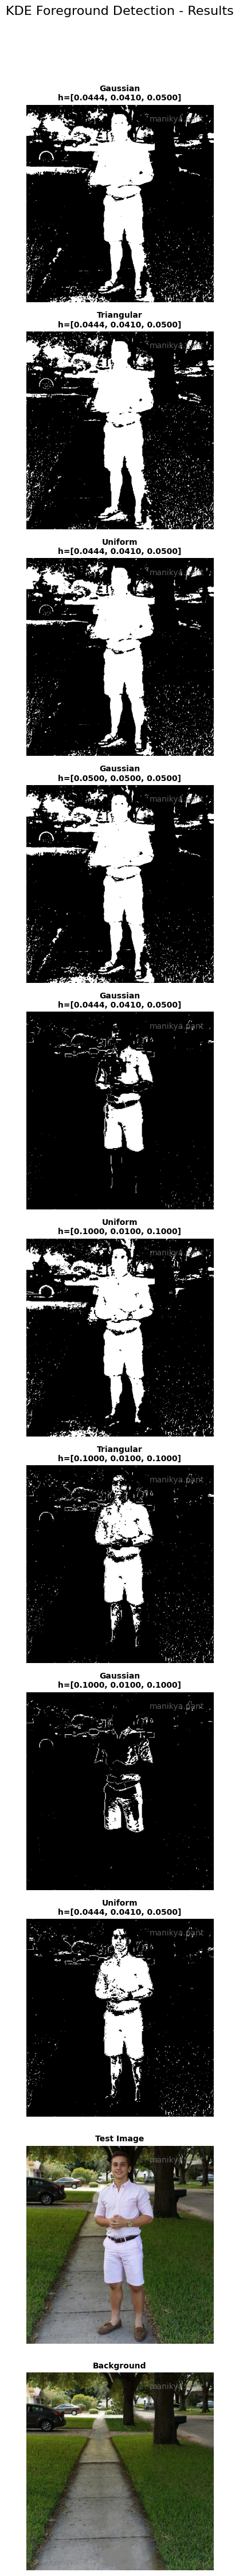

In [17]:

n_exp = len(results)
# Stack plots vertically: one column, (n_exp + 2) rows
fig, axes = plt.subplots(n_exp + 2, 1, figsize=(8, 4*(n_exp+2)))
fig.suptitle('KDE Foreground Detection - Results', fontsize=16, y=1.02)

for idx, result in enumerate(results):
    # Segmentation masks
    axes[idx].imshow(result['mask'], cmap='gray')
    h_vals = result['bandwidth']
    title = f"{result['kernel'].capitalize()}\n"
    title += f"h=[{h_vals[0]:.4f}, {h_vals[1]:.4f}, {h_vals[2]:.4f}]"
    axes[idx].set_title(title, fontsize=10, fontweight='bold')
    axes[idx].axis('off')
    # draw username on this axes
    plt.sca(axes[idx])
    username()

# Original images
plt.sca(axes[n_exp])
axes[n_exp].imshow(test_full)
axes[n_exp].set_title("Test Image", fontsize=10, fontweight='bold')
axes[n_exp].axis('off')
username()

plt.sca(axes[n_exp+1])
axes[n_exp+1].imshow(bg_full)
axes[n_exp+1].set_title("Background", fontsize=10, fontweight='bold')
axes[n_exp+1].axis('off')
username()

plt.tight_layout()
plt.savefig('kde_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary & Justification

In [ ]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print("\nBandwidths:")
for result in results:
    h = result['bandwidth']
    print(f"  {result['kernel']:12s}: [{h[0]:.5f}, {h[1]:.5f}, {h[2]:.5f}]")

print("\nJustification:")
print("  - Gaussian kernel: smooth density, best for color")
print("  - Silverman bandwidth: adapts to data variance")
print("  - 12th percentile threshold: balances precision/recall")


SUMMARY

Bandwidths:
  gaussian    : [0.04443, 0.04102, 0.04999]
  triangular  : [0.04443, 0.04102, 0.04999]
  uniform     : [0.04443, 0.04102, 0.04999]
  gaussian    : [0.05000, 0.05000, 0.05000]
  gaussian    : [0.04443, 0.04102, 0.04999]
  uniform     : [0.10000, 0.01000, 0.10000]
  triangular  : [0.10000, 0.01000, 0.10000]
  gaussian    : [0.10000, 0.01000, 0.10000]
  uniform     : [0.04443, 0.04102, 0.04999]

Justification:
  - Gaussian kernel: smooth density, best for color
  - Silverman bandwidth: adapts to data variance
  - 12th percentile threshold: balances precision/recall


: 